# ift3710 Quick Playground

This notebook shows a compact end-to-end pipeline run for the `ift3710` project using a small California CEED subset.
It demonstrates preprocessing, spatial tensor visualization, and a lightweight model pass using the repository code.


## 1. Environment Setup

Verify the Python environment and required packages before running the demo.


In [18]:
import sys
import os
import importlib.util
from pathlib import Path

ROOT = Path.cwd()
assert (ROOT / 'README.md').exists(), 'Please run this notebook from the repository root.'

print('Repository root:', ROOT)
print('Python version:', sys.version.replace('', ' '))

required_pkgs = [
    'torch',
    'numpy',
    'pandas',
    'matplotlib',
    'geopandas',
    'rasterio',
    'scipy',
    'datasets',
    'huggingface_hub',
    'tqdm',
    'sklearn',
    'einops'
]
missing = []
for pkg in required_pkgs:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

print('Missing packages:', missing)
if missing:
    print('If packages are missing, install them with the repository requirements or `uv sync`.')


Repository root: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710
Python version:  3 . 1 2 . 9   ( m a i n ,   F e b     4   2 0 2 5 ,   1 4 : 3 8 : 3 8 )   [ C l a n g   1 6 . 0 . 0   ( c l a n g - 1 6 0 0 . 0 . 2 6 . 6 ) ] 
Missing packages: []


## 2. Inspect Repository and Data Paths

Confirm the key preprocessing and model files are available, and locate the raw and processed data directories.


In [ ]:
from pathlib import Path

ROOT = Path.cwd()
core_files = [
    ROOT / 'src' / 'main_mutimodal.py',
    ROOT / 'src' / 'data-processing' / 'california' / 'run_preprocessing.sh',
    ROOT / 'src' / 'data-processing' / 'california' / 'ceed_maps_pipeline.py',
    ROOT / 'src' / 'data-processing' / 'california' / 'preprocess_full_pipeline.py',
    ROOT / 'src' / 'safenet_branch' / 'safenet_pipeline_ceed.py'
]
data_dirs = [
    ROOT / 'data' / 'california' 
]

for path in core_files + data_dirs:
    print(path, '->', 'FOUND' if path.exists() else 'MISSING')


/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/main_mutimodal.py -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/main.py -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/data-processing/california/run_preprocessing.sh -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/data-processing/california/ceed_maps_pipeline.py -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/data-processing/california/preprocess_full_pipeline.py -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/safenet_branch/safenet_pipeline_ceed.py -> FOUND
/Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california -> FOUND


## 3. Create a Small CEED Data Subset

This notebook keeps the demo lightweight by processing a small year range instead of the full 1987-2020 dataset.


In [20]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd()
CALIF_DIR = ROOT / 'src' / 'data-processing' / 'california'
sys.path.insert(0, str(CALIF_DIR))

import ceed_maps_pipeline
import ceed_loader
import preprocess_full_pipeline

# Initialize
ceed = ceed_loader.CEEDdataset(catalog_path="data/california/catalog.parquet", base_path="data/california")
# Build catalog (downloads CSV and saves Parquet)
ceed.build_catalog()

print('California pipeline folder:', CALIF_DIR)
print('CEED events file:', preprocess_full_pipeline.EVENTS_CSV)
print('Patch mapping file:', preprocess_full_pipeline.PATCH_CSV)

subset_year_start = 1980
subset_year_end   = 2010
subset_train_year = 2009
subset_test_year  = 2010
print('Using a small subset of years:', subset_year_start, 'to', subset_year_end)
print('Train target year:', subset_train_year, '| Test target year:', subset_test_year)

preprocess_full_pipeline.ensure_patch_csv()

print('Ready to build the California subset pipeline.')

Catalog saved to data/california/catalog.parquet, events: 653642
California pipeline folder: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/src/data-processing/california
CEED events file: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california/events.csv
Patch mapping file: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california/png_list_to_patchxy.csv
Using a small subset of years: 1980 to 2010
Train target year: 2009 | Test target year: 2010
Found /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california/png_list_to_patchxy.csv, skipping generation.
Ready to build the California subset pipeline.


## 4. Run California Preprocessing

Generate the 5-channel tensors and patch arrays for the small year range.


In [21]:
import os
from pathlib import Path
import sys

ROOT = Path.cwd()

print('Working directory for preprocessing:', Path.cwd())

CALIF_DIR = ROOT / 'data' / 'california'
os.chdir(CALIF_DIR)

import ceed_maps_pipeline
import preprocess_full_pipeline

print('Working directory for preprocessing:', Path.cwd())

print('Loading and adapting CEED events for the subset...')
df_small = preprocess_full_pipeline.prepare_dataframe(
    preprocess_full_pipeline.load_and_adapt(subset_year_start, subset_year_end)
)

ceed_maps_pipeline.run_map_pipeline(subset_year_start, subset_year_end, event_csv_path=f"./events_preprocessed_{subset_year_start}_{subset_year_end}.csv")

CEED_DIR = ROOT / "data" / "california"

features_train_file = CEED_DIR / 'ceed_mini_train_output.pickle'
labels_train_file   = CEED_DIR / 'ceed_mini_train_labels.pickle'
features_test_file  = CEED_DIR / 'ceed_mini_test_output.pickle'
labels_test_file    = CEED_DIR / 'ceed_mini_test_labels.pickle'

print('Building mini TRAIN features pickle:', features_train_file)
preprocess_full_pipeline.build_pickle(
    df_small, str(features_train_file),
    norm_start=subset_year_start,
    target_years=[subset_train_year],
)
print('Building mini TRAIN labels pickle:', labels_train_file)
preprocess_full_pipeline.build_labels(
    df_small, str(labels_train_file),
    target_years=[subset_train_year],
)

print('Building mini TEST features pickle:', features_test_file)
preprocess_full_pipeline.build_pickle(
    df_small, str(features_test_file),
    norm_start=subset_year_start,
    target_years=[subset_test_year],
)
print('Building mini TEST labels pickle:', labels_test_file)
preprocess_full_pipeline.build_labels(
    df_small, str(labels_test_file),
    target_years=[subset_test_year],
)

os.chdir(ROOT)
print('Returned to root:', Path.cwd())

Working directory for preprocessing: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710
Working directory for preprocessing: /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california
Loading and adapting CEED events for the subset...
Loading /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california/events.csv...
Assigning patch regions...
Kept 194636 events (1980-2010)
Computing lunar days...
Ready: 194636 events, years 1987-2010
Loading datasets 

Processing year 1980 ...
Calculating eq distribution map ... 
1980: tensor (5, 400, 400) | patches (64, 5, 50, 50)
Processing year 1981 ...
Calculating eq distribution map ... 
1981: tensor (5, 400, 400) | patches (64, 5, 50, 50)
Processing year 1982 ...
Calculating eq distribution map ... 
1982: tensor (5, 400, 400) | patches (64, 5, 50, 50)
Processing year 1983 ...
Calculating eq distribution map ... 
1983: tensor (5, 400, 400) | patches (64, 5, 50, 5

## 5. Load and Visualize Spatial Tensors and Patches

Inspect one of the generated yearly tensors and a few patch examples.


Tensor file exists: True
Patches file exists: True
Tensor shape: (5, 400, 400)
Patches shape: (64, 5, 50, 50)


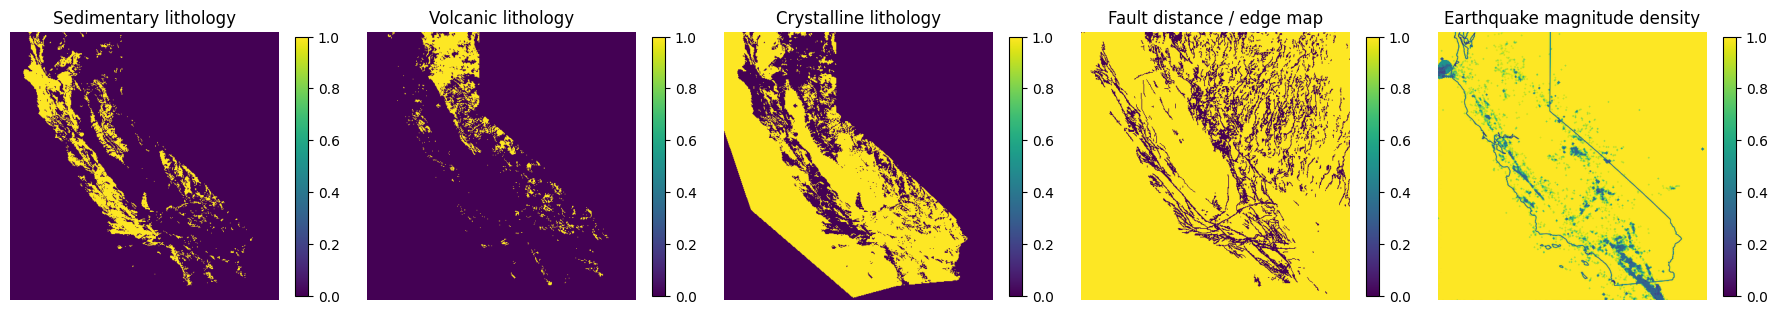

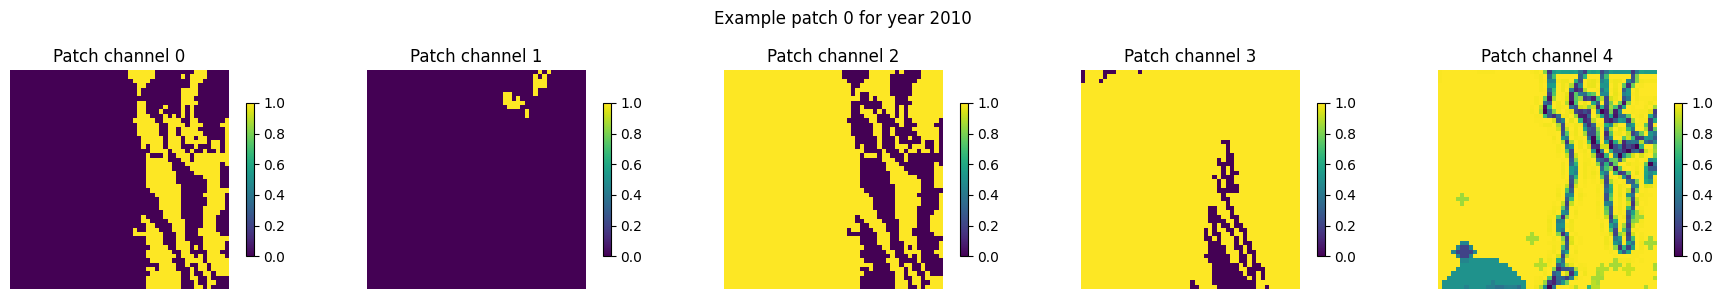

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd()
CALIF_DIR = ROOT / 'data' / 'california'
year = subset_test_year
tensor_path = CALIF_DIR / 'cal_maps' / f'tensor_{year}.npy'
patches_path = CALIF_DIR / 'cal_maps' / f'patches_{year}.npy'

print('Tensor file exists:', tensor_path.exists())
print('Patches file exists:', patches_path.exists())

tensor = np.load(tensor_path)
patches = np.load(patches_path)

print('Tensor shape:', tensor.shape)
print('Patches shape:', patches.shape)

channel_names = [
    'Sedimentary lithology',
    'Volcanic lithology',
    'Crystalline lithology',
    'Fault distance / edge map',
    'Earthquake magnitude density',
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, ax in enumerate(axes):
    im = ax.imshow(tensor[idx], cmap='viridis')
    ax.set_title(channel_names[idx])
    ax.axis('off')
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

sample_patch = patches[0]
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for idx, ax in enumerate(axes):
    im = ax.imshow(sample_patch[idx], cmap='viridis')
    ax.set_title(f'Patch channel {idx}')
    ax.axis('off')
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle(f'Example patch 0 for year {year}')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 6. Run a Lightweight Model Inference

Perform a minimal forward pass with the SafeNet embeddings model on the mini dataset.


In [ ]:
import torch
from pathlib import Path
import sys
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from utils.dataset import MultimodalSafeNetDataset
from models.spatial_models import SeiSM

processed_dir = ROOT / 'data' / 'california'
features_path = processed_dir / 'ceed_mini_train_output.pickle'
labels_path = processed_dir / 'ceed_mini_train_labels.pickle'

dataset = MultimodalSafeNetDataset(str(features_path), str(labels_path))
loader = DataLoader(dataset, batch_size=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = SafeNetEmbeddings(num_classes=4).to(device)

 # --- Inspect sample to determine dimensions ---
sample_inputs, sample_y = dataset[0]
catalog_shape = sample_inputs["catalog"].shape   # (T=10, P+1, 282)
maps_shape = sample_inputs["maps"].shape         # (T=10, P, H, W, C)
num_patches = maps_shape[1]                      # P = regional patches (e.g. 64)
catalog_features = catalog_shape[-1]             # 282
map_channels = maps_shape[-1]

model = SeiSM(
    num_classes=4,
    map_channels=map_channels,
    catalog_features=catalog_features,
    embed_dim=32,
    num_patches=num_patches,
    d_model=128,
    d_state=16,
    n_ssm_layers=2,
).to(device)

checkpoint_path = ROOT / "checkpoints" / "ssm_spatial.pth"

if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    print("Loaded existing checkpoint.")
else:
    print("No checkpoint found. Training from scratch...")
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    model.train()
    for epoch in range(5):  # adjust epochs as needed
        for inputs, labels in loader:
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            logits = logits.mean(dim=1)
            labels = labels[:, 0]
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    torch.save(model.state_dict(), checkpoint_path)
    print(f"Checkpoint saved to {checkpoint_path}")
    
model.eval()

for batch_idx, (inputs, label) in enumerate(loader):
    inputs = {k: v.to(device) for k, v in inputs.items()}
    label = label.to(device)
    with torch.no_grad():
        logits = model(inputs)
        logits = logits.mean(dim=1)  
        label = label[:, 0]
    print('Batch', batch_idx, 'logits shape:', logits.shape)
    print('Label shape:', label.shape)
    break


Loaded existing checkpoint.
Batch 0 logits shape: torch.Size([1, 4])
Label shape: torch.Size([1])


## 7. Display Sample Evaluation Metrics

Compute simple prediction metrics on the mini dataset using the model output.


In [32]:
import sys
from pathlib import Path
from torch.utils.data import DataLoader
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from utils.dataset import MultimodalSafeNetDataset
from models.safenet_embeddings import SafeNetEmbeddings
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

features_path = processed_dir / 'ceed_mini_train_output.pickle'
labels_path = processed_dir / 'ceed_mini_train_labels.pickle'

dataset = MultimodalSafeNetDataset(str(features_path), str(labels_path))
loader = DataLoader(dataset, batch_size=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Inspect sample to determine dimensions ---
sample_inputs, sample_y = dataset[0]
catalog_shape = sample_inputs["catalog"].shape   # (T=10, P+1, 282)
maps_shape = sample_inputs["maps"].shape         # (T=10, P, H, W, C)
num_patches = maps_shape[1]                      # P = regional patches (e.g. 64)
catalog_features = catalog_shape[-1]             # 282
map_channels = maps_shape[-1]

model = SeiSM(
    num_classes=4,
    map_channels=map_channels,
    catalog_features=catalog_features,
    embed_dim=32,
    num_patches=num_patches,
    d_model=128,
    d_state=16,
    n_ssm_layers=2,
).to(device)

checkpoint_path = ROOT / "checkpoints" / "ssm_spatial.pth" 
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for inputs, label in loader:
        inputs = {k: v.to(device) for k, v in inputs.items()}
        logits = model(inputs)
        pred = logits.argmax(dim=-1).cpu().numpy().ravel()
        true = label.cpu().numpy().ravel()
        pred_labels.extend(pred.tolist())
        true_labels.extend(true.tolist())

print('\n---Evaluation metrics for earthquake prediction of the year 2011---')
print('Samples:', len(true_labels))
print('Accuracy:', accuracy_score(true_labels, pred_labels))
print('Macro F1:', f1_score(true_labels, pred_labels, average='macro', zero_division=0))
print('Macro precision:', precision_score(true_labels, pred_labels, average='macro', zero_division=0))
print('Macro recall:', recall_score(true_labels, pred_labels, average='macro', zero_division=0))

labels_list = [0, 1, 2, 3]
class_names = ["M<5", "M5-6", "M6-7", "M≥7"] 
f1_per_class = f1_score(true_labels, pred_labels, labels=labels_list, average=None, zero_division=0)
precision_per_class = precision_score(true_labels, pred_labels, labels=labels_list, average=None, zero_division=0)

recall_per_class = recall_score(true_labels, pred_labels, labels=labels_list, average=None, zero_division=0)
class_weights = np.array([1.0, 4.0, 15.0, 78.0])
weighted_f1 = np.average(f1_per_class, weights=class_weights)
print(f'Custom Weighted F1: {weighted_f1:.4f}')
print('\n--- Per-Class Breakdown ---')
for i in range(4):
    print(f"Class {i} ({class_names[i]:4s}) | "
          f"Accuracy: {recall_per_class[i]:.4f} | "
          f"Precision: {precision_per_class[i]:.4f} | "
          f"F1: {f1_per_class[i]:.4f}")



---Evaluation metrics for earthquake prediction of the year 2011---
Samples: 64
Accuracy: 0.953125
Macro F1: 0.7853641456582633
Macro precision: 0.7457627118644068
Macro recall: 0.8666666666666667
Custom Weighted F1: 0.7140

--- Per-Class Breakdown ---
Class 0 (M<5 ) | Accuracy: 0.9667 | Precision: 0.9831 | F1: 0.9748
Class 1 (M5-6) | Accuracy: 0.5000 | Precision: 0.5000 | F1: 0.5000
Class 2 (M6-7) | Accuracy: 1.0000 | Precision: 1.0000 | F1: 1.0000
Class 3 (M≥7 ) | Accuracy: 1.0000 | Precision: 0.5000 | F1: 0.6667


## 8. Run our End-to-End training pipeline

This will demonstrate how to run our Safenet pipeline end-to-end (from pre-processing raw data to training the SSM for one epoch & display evals metrics)

In [27]:
from pathlib import Path
import sys

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from safenet_branch.safenet_pipeline import SafeNetPipeline
from safenet_branch.safenet_config import PipelineConfig

DATA_DIR   = ROOT / "data" / "california"
SCRIPT_DIR = ROOT / "src" / "data-processing" / "california"

cfg = PipelineConfig(
    disable_wandb=True,
    num_epochs=1 # 1 to avoid overfitting on the mini subset
    )

pipeline = SafeNetPipeline(
    data_dir             = DATA_DIR,
    preprocessing_script = SCRIPT_DIR / "run_preprocessing.sh",
    training_pickle      = "ceed_mini_train_output.pickle",
    training_labels      = "ceed_mini_train_labels.pickle",
    testing_pickle       = "ceed_mini_test_output.pickle",
    testing_labels       = "ceed_mini_test_labels.pickle",
    num_patches          = cfg.num_patches,
    num_epochs           = cfg.num_epochs,
    learning_rate        = cfg.learning_rate,
    focal_gamma          = cfg.focal_gamma,
    class_weights        = cfg.class_weights_tensor(),
    ssm_d_model          = cfg.ssm_d_model,
    ssm_d_state          = cfg.ssm_d_state,
    ssm_n_layers         = cfg.ssm_n_layers,
    wandb_run            = None,
    wandb_log_freq       = cfg.wandb_log_freq,
)

pipeline.smoke_test()
pipeline.train(skip_preprocessing=True)

# Evaluate on test set after training
model = pipeline._load_checkpoint()
_, test_loader = pipeline._get_loaders(shuffle_train=False)
metrics = pipeline._evaluate_split(model, test_loader)

# Reconstruct labels/preds for sklearn printing
import torch
import numpy as np

all_preds, all_labels = [], []
model.eval
with torch.no_grad():
    for inputs, labels in test_loader:
        logits, _ = pipeline._forward(model, inputs)
        all_preds.append(logits.argmax(dim=-1).cpu().reshape(-1))
        all_labels.append(labels.reshape(-1))

true_labels = torch.cat(all_labels).numpy()
pred_labels = torch.cat(all_preds).numpy()

print('Samples:',         len(true_labels))
print('Accuracy:',        accuracy_score(true_labels, pred_labels))
print('Macro F1:',        f1_score(true_labels, pred_labels, average='macro', zero_division=0))
print('Macro precision:', precision_score(true_labels, pred_labels, average='macro', zero_division=0))
print('Macro recall:',    recall_score(true_labels, pred_labels, average='macro', zero_division=0))

Smoke test: SeiSM (64 patches)
  Catalog Input shape : torch.Size([2, 10, 65, 282])
  Maps Input shape    : torch.Size([2, 10, 64, 50, 50, 5])
  Output shape        : torch.Size([2, 64, 4])  <- (batch, patches, num_classes)
  Device              : cpu
  Params              : 912,192


Step 2: Loading data...
  Training samples : 1
  Testing  samples : 1

Step 3: Building model...
  Model params     : 912,192

Step 4: Training for 1 epochs...
  Epoch 1/1  loss: 1.0895  acc: 0.2188
    Test  loss: 1.0070  acc: 0.1719  macro-F1: 0.0733
    *** New best checkpoint saved (F1: 0.0733) → /Users/fauverick/Documents/UdeM - Informatique/Hiver 2026/IFT 3710/ift3710/data/california/checkpoint.pt ***

  Training time: 1.8s

Final metrics on test set:
  Accuracy         : 0.1719
  Macro F1         : 0.0733
  Weighted F1      : 0.2933

  Per-class breakdown:
  Class         Prec       Rec        F1   Support
  M<5         1.0000    0.1719    0.2933        64
  M5-6        0.0000    0.0000    0.0000  